In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
appearances = pd.read_csv('datasets/player_appearances.csv')
team_apps = pd.read_csv('datasets/team_appearances.csv')
tm_values = pd.read_csv('tm_values.csv')

In [ ]:
#Converting values into more readable numbers. People often say a player is worth (23 mil). 

tm_values['value_m'] = tm_values['value_eur'] / 1_000_000
tm_values[['player_id', 'tournament_id', 'value_m']].head(10)

,player_id,tournament_id,value_m
0,P-00465,WC-2022,17.00
1,P-00916,WC-2006,6.00
2,P-01416,WC-2014,25.00
3,P-01730,WC-2018,7.00
4,P-02231,WC-2014,15.00
5,P-02328,WC-2006,5.00
6,P-02328,WC-2010,15.00
7,P-02328,WC-2014,16.00
8,P-02609,WC-2018,1.25
9,P-03265,WC-2022,28.00


Check distribution of the data

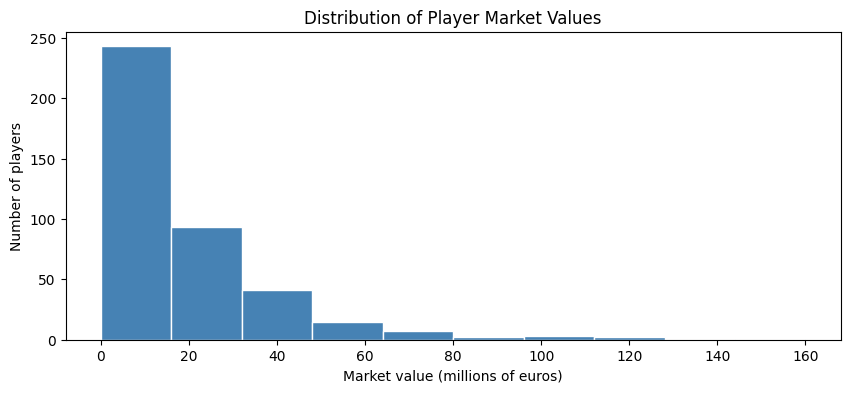

In [4]:
plt.figure(figsize=(10, 4))
plt.hist(tm_values['value_m'].dropna(), color='steelblue', edgecolor='white')
plt.xlabel('Market value (millions of euros)')
plt.ylabel('Number of players')
plt.title('Distribution of Player Market Values')
plt.show()

Data appears to be heavily right skewed. This makes sense given the way transfer values are attributed. Much easier to jsutify a 30 mil evaluation over a 100 mil evalulation. Also consider that these values are not adjusted for inflation. Chose to apply a log transformation to make it closer a unfiform distribution.

In [5]:
tm_values['log_value'] = np.log1p(tm_values['value_m'])
tm_values[['player_id', 'tournament_id', 'value_m', 'log_value']].head(10)

,player_id,tournament_id,value_m,log_value
0,P-00465,WC-2022,17.00,2.890372
1,P-00916,WC-2006,6.00,1.945910
2,P-01416,WC-2014,25.00,3.258097
3,P-01730,WC-2018,7.00,2.079442
4,P-02231,WC-2014,15.00,2.772589
5,P-02328,WC-2006,5.00,1.791759
6,P-02328,WC-2010,15.00,2.772589
7,P-02328,WC-2014,16.00,2.833213
8,P-02609,WC-2018,1.25,0.810930
9,P-03265,WC-2022,28.00,3.367296


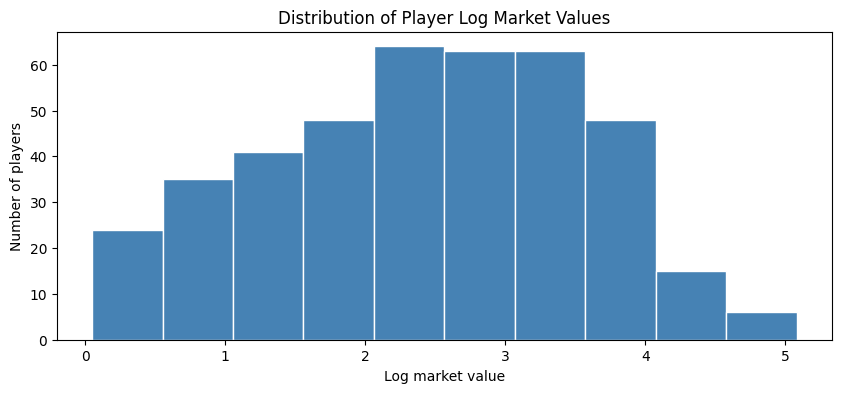

In [7]:
plt.figure(figsize=(10, 4))
plt.hist(tm_values['log_value'].dropna(), color='steelblue', edgecolor='white')
plt.xlabel('Log market value')
plt.ylabel('Number of players')
plt.title('Distribution of Player Log Market Values')
plt.show()

Start grouping the players with the teams they played for in each year. That way we can start attributing market values to each team. 

In [8]:
starters = appearances[appearances['starter'] == 1]

starters_grouped = starters.groupby(
    ['player_id', 'tournament_id', 'team_code', 'team_name'],
    as_index=False
).agg(matches_started=('starter', 'sum'))

merged = starters_grouped.merge(
    tm_values[['player_id', 'tournament_id', 'log_value']],
    on=['player_id', 'tournament_id'],
    how='inner'
)

print('Merged rows:', len(merged))
merged.head()

Merged rows: 407


,player_id,tournament_id,team_code,team_name,matches_started,log_value
0,P-00465,WC-2022,FRA,France,1,2.890372
1,P-00916,WC-2006,FRA,France,2,1.945910
2,P-01416,WC-2014,ESP,Spain,3,3.258097
3,P-01730,WC-2018,MEX,Mexico,4,2.079442
4,P-02231,WC-2014,ESP,Spain,2,2.772589


Start comparing the values of the players per team

In [9]:
team_values = merged.groupby(
    ['team_code', 'tournament_id'],
    as_index=False
).agg(
    mean_value=('log_value', 'mean'),
    median_value=('log_value', 'median'),
    total_value=('log_value', 'sum'),
    n_starters=('log_value', 'count')
)

team_values = team_values.round(3)
team_values.sort_values(['tournament_id', 'mean_value'], ascending=[True, False])

,team_code,tournament_id,mean_value,median_value,total_value,n_starters
16,ITA,WC-2006,2.783,2.889,44.530,16
12,FRA,WC-2006,2.529,2.375,35.404,14
6,DEU,WC-2006,1.953,1.869,31.251,16
10,ESP,WC-2010,3.242,3.367,45.381,14
17,ITA,WC-2010,2.522,2.639,32.781,13
20,NLD,WC-2010,2.445,2.398,34.235,14
7,DEU,WC-2010,1.801,2.047,28.811,16
23,PRY,WC-2010,1.362,1.224,23.152,17
24,SVK,WC-2010,1.340,1.267,18.758,14
22,NZL,WC-2010,0.508,0.405,4.573,9


Creating a data frame to begin the regression piece.

In [10]:
champions = pd.DataFrame([
    {'team_code': 'ITA', 'won_year': 'WC-2006', 'next_year': 'WC-2010'},
    {'team_code': 'ESP', 'won_year': 'WC-2010', 'next_year': 'WC-2014'},
    {'team_code': 'DEU', 'won_year': 'WC-2014', 'next_year': 'WC-2018'},
    {'team_code': 'FRA', 'won_year': 'WC-2018', 'next_year': 'WC-2022'},
])

champions

,team_code,won_year,next_year
0,ITA,WC-2006,WC-2010
1,ESP,WC-2010,WC-2014
2,DEU,WC-2014,WC-2018
3,FRA,WC-2018,WC-2022


Now we are going to compare the value of the world cup winning teams in their world cup winning years and the following world cup.

In [11]:
rows = []

for i in range(len(champions)):
    team = champions.iloc[i]['team_code']
    won = champions.iloc[i]['won_year']
    nxt = champions.iloc[i]['next_year']
    
    won_squad = team_values[(team_values['team_code'] == team) & (team_values['tournament_id'] == won)]
    nxt_squad = team_values[(team_values['team_code'] == team) & (team_values['tournament_id'] == nxt)]
    
    won_mean = won_squad['mean_value'].iloc[0]
    nxt_mean = nxt_squad['mean_value'].iloc[0]
    
    rows.append({
        'champion': team,
        'won_year': won,
        'won_year_mean_value': round(won_mean, 3),
        'next_year': nxt,
        'next_year_mean_value': round(nxt_mean, 3),
        'change': round(nxt_mean - won_mean, 3),
        'percent_change': round(100 * (nxt_mean - won_mean) / won_mean, 1)
    })

squad_compare = pd.DataFrame(rows)
squad_compare

,champion,won_year,won_year_mean_value,next_year,next_year_mean_value,change,percent_change
0,ITA,WC-2006,2.783,WC-2010,2.522,-0.261,-9.4
1,ESP,WC-2010,3.242,WC-2014,3.140,-0.102,-3.1
2,DEU,WC-2014,2.873,WC-2018,3.466,0.593,20.6
3,FRA,WC-2018,3.766,WC-2022,3.519,-0.247,-6.6


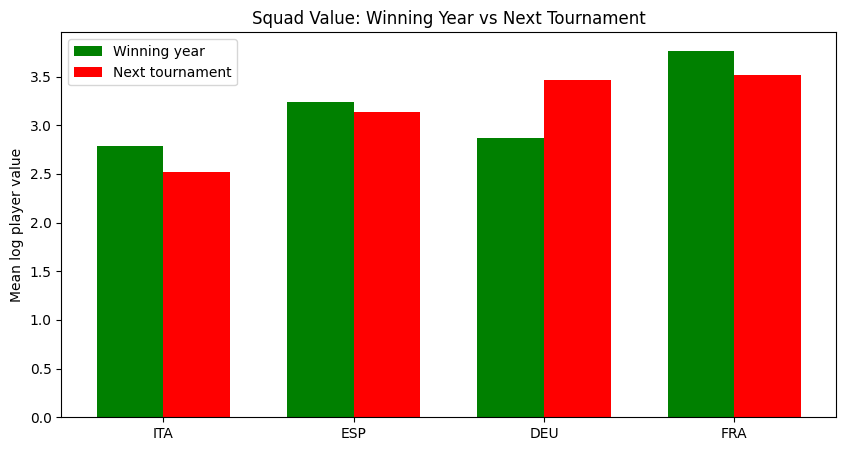

In [14]:
x = np.arange(len(squad_compare))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, squad_compare['won_year_mean_value'], width, label='Winning year', color='green')
plt.bar(x + width/2, squad_compare['next_year_mean_value'], width, label='Next tournament', color='red')
plt.xticks(x, squad_compare['champion'])
plt.ylabel('Mean log player value')
plt.title('Squad Value: Winning Year vs Next Tournament')
plt.legend()
plt.show()

Visually, the mean of the squad value stayed pretty close. Even increasing in the case of Germany, one would believe that they have a "better squad".

In [15]:
squad_long_rows = []

for i in range(len(champions)):
    team = champions.iloc[i]['team_code']
    won = champions.iloc[i]['won_year']
    nxt = champions.iloc[i]['next_year']
    
    won_value = team_values[(team_values['team_code'] == team) & (team_values['tournament_id'] == won)]['mean_value'].iloc[0]
    nxt_value = team_values[(team_values['team_code'] == team) & (team_values['tournament_id'] == nxt)]['mean_value'].iloc[0]
    
    squad_long_rows.append({'champion': team, 'tournament': won, 'squad_value': won_value, 'is_winning_year': 1})
    squad_long_rows.append({'champion': team, 'tournament': nxt, 'squad_value': nxt_value, 'is_winning_year': 0})

squad_long = pd.DataFrame(squad_long_rows)
squad_long

,champion,tournament,squad_value,is_winning_year
0,ITA,WC-2006,2.783,1
1,ITA,WC-2010,2.522,0
2,ESP,WC-2010,3.242,1
3,ESP,WC-2014,3.140,0
4,DEU,WC-2014,2.873,1
5,DEU,WC-2018,3.466,0
6,FRA,WC-2018,3.766,1
7,FRA,WC-2022,3.519,0


In [16]:
X = sm.add_constant(squad_long[['is_winning_year']])
y = squad_long['squad_value']

squad_model = sm.OLS(y, X).fit()
print(squad_model.summary())

                            OLS Regression Results                            
Dep. Variable:            squad_value   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.167
Method:                 Least Squares   F-statistic:                 0.0001765
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.990
Time:                        19:23:37   Log-Likelihood:                -3.8561
No. Observations:                   8   AIC:                             11.71
Df Residuals:                       6   BIC:                             11.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.1617      0.226     

With a very low sample size, it would have been hard to believe that something like this would have been statistiaclly significant, the summary confirms it given 0.9 P value.

Now we repeat the same process but for the opponents.

In [17]:
opponents = pd.DataFrame([
    {'champion': 'ITA', 'tournament': 'WC-2006', 'role': 'semifinal', 'opponent': 'DEU'},
    {'champion': 'ITA', 'tournament': 'WC-2006', 'role': 'final', 'opponent': 'FRA'},
    {'champion': 'ITA', 'tournament': 'WC-2010', 'role': 'group', 'opponent': 'PRY'},
    {'champion': 'ITA', 'tournament': 'WC-2010', 'role': 'group', 'opponent': 'SVK'},
    {'champion': 'ITA', 'tournament': 'WC-2010', 'role': 'group', 'opponent': 'NZL'},
    
    {'champion': 'ESP', 'tournament': 'WC-2010', 'role': 'semifinal', 'opponent': 'DEU'},
    {'champion': 'ESP', 'tournament': 'WC-2010', 'role': 'final', 'opponent': 'NLD'},
    {'champion': 'ESP', 'tournament': 'WC-2014', 'role': 'group', 'opponent': 'NLD'},
    {'champion': 'ESP', 'tournament': 'WC-2014', 'role': 'group', 'opponent': 'CHL'},
    {'champion': 'ESP', 'tournament': 'WC-2014', 'role': 'group', 'opponent': 'AUS'},
    
    {'champion': 'DEU', 'tournament': 'WC-2014', 'role': 'semifinal', 'opponent': 'BRA'},
    {'champion': 'DEU', 'tournament': 'WC-2014', 'role': 'final', 'opponent': 'ARG'},
    {'champion': 'DEU', 'tournament': 'WC-2018', 'role': 'group', 'opponent': 'SWE'},
    {'champion': 'DEU', 'tournament': 'WC-2018', 'role': 'group', 'opponent': 'MEX'},
    {'champion': 'DEU', 'tournament': 'WC-2018', 'role': 'group', 'opponent': 'KOR'},
    
    {'champion': 'FRA', 'tournament': 'WC-2018', 'role': 'semifinal', 'opponent': 'BEL'},
    {'champion': 'FRA', 'tournament': 'WC-2018', 'role': 'final', 'opponent': 'HRV'},
    {'champion': 'FRA', 'tournament': 'WC-2022', 'role': 'final_lost', 'opponent': 'ARG'},
])

opponents

,champion,tournament,role,opponent
0,ITA,WC-2006,semifinal,DEU
1,ITA,WC-2006,final,FRA
2,ITA,WC-2010,group,PRY
3,ITA,WC-2010,group,SVK
4,ITA,WC-2010,group,NZL
5,ESP,WC-2010,semifinal,DEU
6,ESP,WC-2010,final,NLD
7,ESP,WC-2014,group,NLD
8,ESP,WC-2014,group,CHL
9,ESP,WC-2014,group,AUS


In [18]:
opponents_with_values = opponents.merge(
    team_values[['team_code', 'tournament_id', 'mean_value']].rename(
        columns={'team_code': 'opponent', 'tournament_id': 'tournament', 'mean_value': 'opponent_value'}
    ),
    on=['opponent', 'tournament'],
    how='left'
)

opponents_with_values

,champion,tournament,role,opponent,opponent_value
0,ITA,WC-2006,semifinal,DEU,1.953
1,ITA,WC-2006,final,FRA,2.529
2,ITA,WC-2010,group,PRY,1.362
3,ITA,WC-2010,group,SVK,1.340
4,ITA,WC-2010,group,NZL,0.508
5,ESP,WC-2010,semifinal,DEU,1.801
6,ESP,WC-2010,final,NLD,2.445
7,ESP,WC-2014,group,NLD,2.152
8,ESP,WC-2014,group,CHL,1.732
9,ESP,WC-2014,group,AUS,0.655


In [19]:
rows = []

for i in range(len(champions)):
    team = champions.iloc[i]['team_code']
    won = champions.iloc[i]['won_year']
    nxt = champions.iloc[i]['next_year']
    
    won_opps = opponents_with_values[
        (opponents_with_values['champion'] == team) & 
        (opponents_with_values['tournament'] == won)
    ]
    nxt_opps = opponents_with_values[
        (opponents_with_values['champion'] == team) & 
        (opponents_with_values['tournament'] == nxt)
    ]
    
    rows.append({
        'champion': team,
        'won_year_avg_opponent': round(won_opps['opponent_value'].mean(), 3),
        'next_year_avg_opponent': round(nxt_opps['opponent_value'].mean(), 3),
        'change': round(nxt_opps['opponent_value'].mean() - won_opps['opponent_value'].mean(), 3)
    })

opp_compare = pd.DataFrame(rows)
opp_compare

,champion,won_year_avg_opponent,next_year_avg_opponent,change
0,ITA,2.241,1.070,-1.171
1,ESP,2.123,1.513,-0.610
2,DEU,2.770,1.557,-1.212
3,FRA,2.874,2.993,0.119


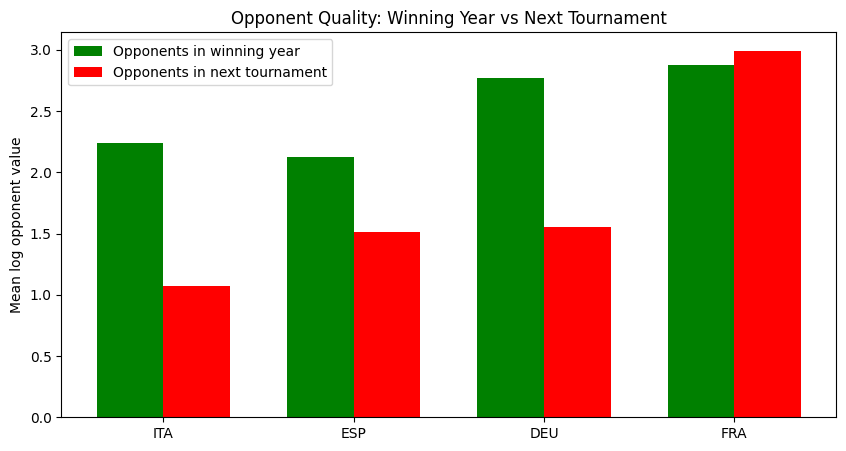

In [20]:
x = np.arange(len(opp_compare))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, opp_compare['won_year_avg_opponent'], width, label='Opponents in winning year', color='green')
plt.bar(x + width/2, opp_compare['next_year_avg_opponent'], width, label='Opponents in next tournament', color='red')
plt.xticks(x, opp_compare['champion'])
plt.ylabel('Mean log opponent value')
plt.title('Opponent Quality: Winning Year vs Next Tournament')
plt.legend()
plt.show()

Interestingly, only France were elimatated by teams better than who they faced in their world cup winning year. Showing a major decline in the other team's performance. 

In [21]:
opp_long_rows = []

for i in range(len(champions)):
    team = champions.iloc[i]['team_code']
    won = champions.iloc[i]['won_year']
    nxt = champions.iloc[i]['next_year']
    
    won_opps = opponents_with_values[
        (opponents_with_values['champion'] == team) & 
        (opponents_with_values['tournament'] == won)
    ]
    nxt_opps = opponents_with_values[
        (opponents_with_values['champion'] == team) & 
        (opponents_with_values['tournament'] == nxt)
    ]
    
    opp_long_rows.append({'champion': team, 'tournament': won, 'opponent_value': won_opps['opponent_value'].mean(), 'is_winning_year': 1})
    opp_long_rows.append({'champion': team, 'tournament': nxt, 'opponent_value': nxt_opps['opponent_value'].mean(), 'is_winning_year': 0})

opp_long = pd.DataFrame(opp_long_rows)
opp_long

,champion,tournament,opponent_value,is_winning_year
0,ITA,WC-2006,2.2410,1
1,ITA,WC-2010,1.0700,0
2,ESP,WC-2010,2.1230,1
3,ESP,WC-2014,1.5130,0
4,DEU,WC-2014,2.7695,1
5,DEU,WC-2018,1.5570,0
6,FRA,WC-2018,2.8740,1
7,FRA,WC-2022,2.9930,0


In [22]:
X = sm.add_constant(opp_long[['is_winning_year']])
y = opp_long['opponent_value']

opp_model = sm.OLS(y, X).fit()
print(opp_model.summary())

                            OLS Regression Results                            
Dep. Variable:         opponent_value   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     2.461
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.168
Time:                        19:24:15   Log-Likelihood:                -6.7278
No. Observations:                   8   AIC:                             17.46
Df Residuals:                       6   BIC:                             17.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.7832      0.324     

We have a similar story here, we have a P value of 0.168 meaning that the relationship isn't significant.